In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Define a Basic Block for ResNet
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.residual_function = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        return nn.ReLU(inplace=True)(self.residual_function(x) + self.shortcut(x))

# Define ResNet Model
class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = nn.AdaptiveAvgPool2d((1, 1))(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# Define ResNet18
def ResNet18(num_classes):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes)

In [ ]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load dataset
train_dataset = datasets.ImageFolder(root="/content/drive/MyDrive/Asma_dataset/train", transform=transform)
val_dataset = datasets.ImageFolder(root="/content/drive/MyDrive/Asma_dataset/val", transform=transform)

# Dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Class names
class_names = train_dataset.classes

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model
model = ResNet18(len(class_names)).to(device)  # Transfer learning
# model.fc = nn.Linear(model.fc.in_features, len(class_names))  # Adjust output layer
# model = model.to(device)

In [14]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 10
train_losses, val_losses, train_acc, val_acc = [], [], [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    train_losses.append(running_loss / len(train_loader))
    train_acc.append(100 * correct / len(train_dataset))

    # Validation loop
    model.eval()
    running_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    val_losses.append(running_loss / len(val_loader))
    val_acc.append(100 * correct / len(val_dataset))
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}, Train Acc: {train_acc[-1]:.2f}%, Val Acc: {val_acc[-1]:.2f}%")

Validation: 100%|██████████| 18/18 [00:24<00:00,  1.36s/it]


Epoch 1/10, Train Loss: 1.8640, Val Loss: 1.8094, Train Acc: 35.22%, Val Acc: 38.90%


Validation: 100%|██████████| 18/18 [00:25<00:00,  1.40s/it]


Epoch 2/10, Train Loss: 1.4861, Val Loss: 1.8776, Train Acc: 47.37%, Val Acc: 41.74%


Validation: 100%|██████████| 18/18 [00:25<00:00,  1.44s/it]


...

Epoch 8/10, Train Loss: 0.7036, Val Loss: 0.6463, Train Acc: 75.66%, Val Acc: 78.33%


Validation: 100%|██████████| 18/18 [00:25<00:00,  1.42s/it]


Epoch 9/10, Train Loss: 0.6424, Val Loss: 0.6438, Train Acc: 78.68%, Val Acc: 77.26%


Validation: 100%|██████████| 18/18 [00:26<00:00,  1.46s/it]

Epoch 10/10, Train Loss: 0.5976, Val Loss: 0.4531, Train Acc: 80.39%, Val Acc: 83.84%


Evaluation: 100%|██████████| 18/18 [00:27<00:00,  1.52s/it]


Classification Report:
                 precision    recall  f1-score   support

      HALALA 1       0.85      0.91      0.88        32
     HALALA 25       0.65      0.34      0.45        44
     HALALA 50       0.50      0.79      0.61        33
       RIYAL 1       0.95      0.91      0.93        46
 RIYAL 10 NOTE       0.94      0.94      0.94        47
RIYAL 100 NOTE       0.76      0.96      0.85        52
       RIYAL 2       0.79      0.80      0.80        46
 RIYAL 20 NOTE       0.83      0.97      0.89        35
RIYAL 200 NOTE       0.88      0.79      0.84        29
  RIYAL 5 NOTE       0.94      0.86      0.90        97
 RIYAL 50 NOTE       0.98      1.00      0.99        48
RIYAL 500 NOTE       0.89      0.76      0.82        54

      accuracy                           0.84       563
     macro avg       0.83      0.84      0.82       563
  weighted avg       0.85      0.84      0.83       563



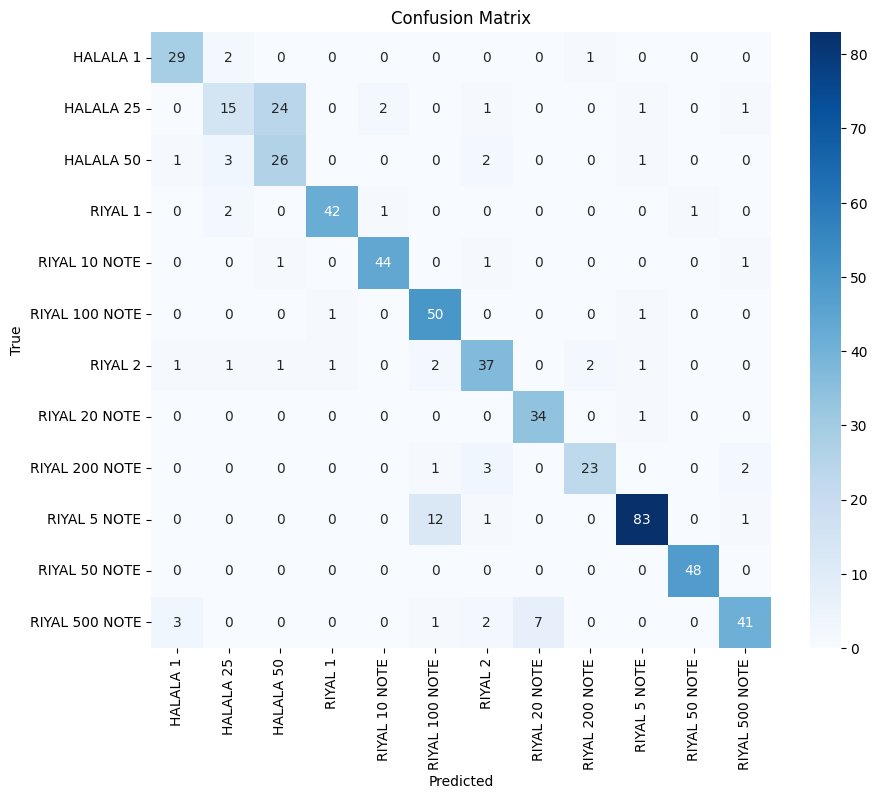

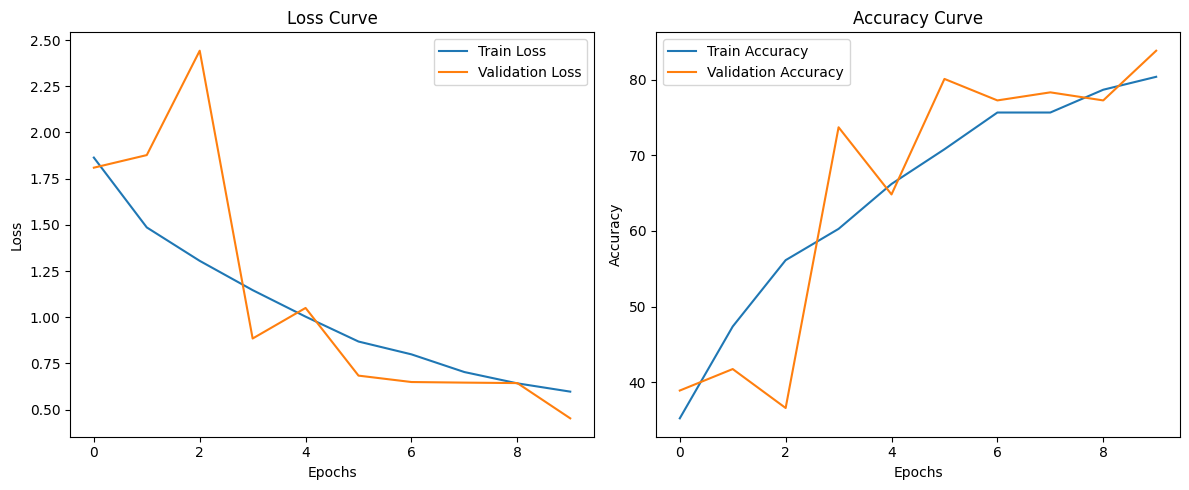

In [15]:
# Classification Report and Confusion Matrix
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluation"):
        images = images.to(device)
        outputs = model(images)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(outputs.argmax(1).cpu().numpy())

print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Loss and Accuracy Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
torch.save(model, "resnet18_custom_model.pth")